In [ ]:
import pandas as pd
from pandas.io.formats.style import Styler # Para a tipagem do retorno

def analisar_risco(df: pd.DataFrame, coluna: str) -> Styler:
    """
    Gera uma tabela de frequência bivariada analisando o risco (target)
    por categoria de uma coluna específica.
    
    Args:
        df (pd.DataFrame): O DataFrame contendo os dados.
        coluna (str): O nome da coluna categórica a ser analisada.
        
    Returns:
        pd.io.formats.style.Styler: Objeto de estilo do Pandas para visualização.
    """
    
    # --- 1. ASSERTS (O "Crachá de Segurança") ---
    # Garante que o df é mesmo um DataFrame
    assert isinstance(df, pd.DataFrame), "Erro: O argumento 'df' precisa ser um Pandas DataFrame."
    
    # Garante que a coluna existe (evita aquele erro gigante de KeyError depois)
    assert coluna in df.columns, f"Erro: A coluna '{coluna}' não foi encontrada no DataFrame."
    
    # Garante que o target existe (premissa básica da função)
    assert 'target' in df.columns, "Erro: O DataFrame precisa ter uma coluna chamada 'target'."
    
    # Garante que não estamos analisando um dataset vazio
    assert not df.empty, "Erro: O DataFrame está vazio!"

    # --- 2. LÓGICA DE NEGÓCIO ---
    # Agrupa e calcula
    tabela = df.groupby(coluna)['target'].agg(['count', 'mean'])
    
    # Renomeia
    tabela.columns = ['Qtd_Clientes', 'Bad_Rate']
    
    # Ordena do maior risco para o menor
    tabela = tabela.sort_values(by='Bad_Rate', ascending=False)
    
    # --- 3. RETORNO VISUAL ---
    print(f"--- Relatório de Risco: {coluna.upper()} ---")
    media_geral = df['target'].mean()
    print(f"Média Geral do Portfólio: {media_geral:.2%}\n")
    
    return tabela.style.format({
        'Bad_Rate': '{:.2%}',
        'Qtd_Clientes': '{:,}'
    }).background_gradient(cmap='Reds', subset='Bad_Rate')

# Nomes das colunas baseados na documentação "german.doc"
col_names = [
    'checking_account', 'duration_months', 'credit_history', 'purpose', 
    'credit_amount', 'savings_account', 'employment_since', 'installment_rate', 
    'status_sex', 'other_debtors', 'residence_since', 'property', 
    'age', 'other_installment_plans', 'housing','existing_credits',
    'job', 'people_liable', 'telephone', 'foreign_worker', 'target'
]

# Carregando o arquivo cru (sem header), separando por espaço
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
df = pd.read_csv(url, header=None, names=col_names)

# Ajuste Rápido no Target para o padrão de mercado (0 e 1)
# Original: 1 (Bom), 2 (Ruim)
# Padrão Data Science: 0 (Bom/Não-Evento), 1 (Ruim/Evento/Fraude)
# df['target'] = df['target'].map({1: 0, 2: 1})

# Visualizar
# print(df.head())
print(df['target'])



0      1
1      2
2      1
3      1
4      2
      ..
995    1
996    1
997    1
998    2
999    1
Name: target, Length: 1000, dtype: int64


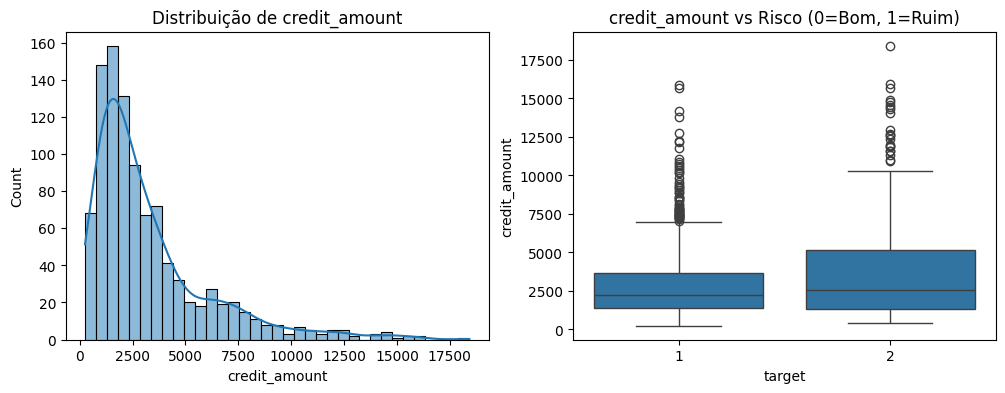

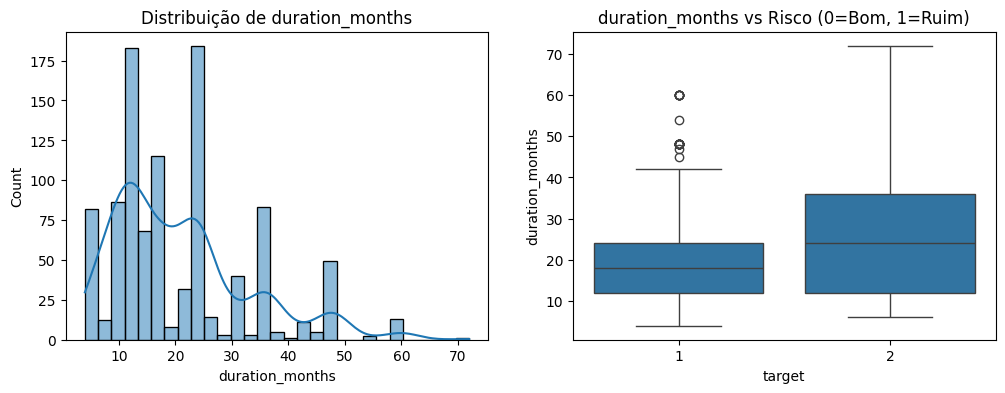

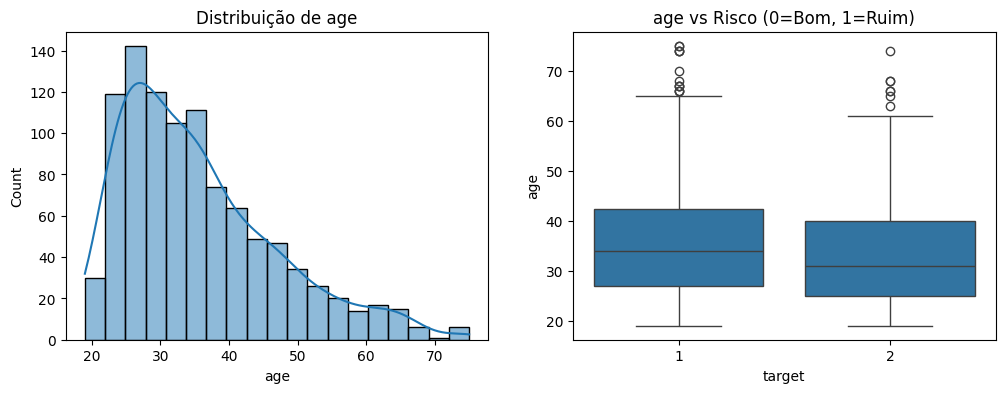

--- Análise de Quartis: duration_months ---
                         Volume (Qtd)  Risco (Bad Rate %)
duration_months_quartil                                  
(3.999, 12.0]                     359              121.17
(12.0, 18.0]                      187              129.95
(18.0, 24.0]                      224              129.46
(24.0, 72.0]                      230              144.35
------------------------------

--- Análise de Quartis: credit_amount ---
                       Volume (Qtd)  Risco (Bad Rate %)
credit_amount_quartil                                  
(249.999, 1365.5]               250               130.8
(1365.5, 2319.5]                250               124.8
(2319.5, 3972.25]               250               122.4
(3972.25, 18424.0]              250               142.0
------------------------------

--- Análise de Quartis: age ---
                Volume (Qtd)  Risco (Bad Rate %)
age_quartil                                     
(18.999, 27.0]           291        

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
### ANALISE DE VARIÁVEIS QUANTITATIVAS
def analisar_numerica(df, col, target='target'):
    plt.figure(figsize=(12, 4))
    
    # 1. Histograma (Distribuição)
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição de {col}')
    
    # 2. Boxplot por Target (Para ver se separa bem)
    plt.subplot(1, 2, 2)
    sns.boxplot(x=target, y=col, data=df)
    plt.title(f'{col} vs Risco (0=Bom, 1=Ruim)')
    
    plt.show()

def analisar_risco_por_quartil(df, col, target='target'):
    # Cria uma coluna temporária com os quartis (0, 1, 2, 3)
    # duplicates='drop' é vital aqui porque se muitos clientes tiverem exatamente 
    # o mesmo valor (ex: muitos com 24 meses), os quartis podem se sobrepor.
    try:
        df[f'{col}_quartil'] = pd.qcut(df[col], q=4, duplicates='drop')
    except ValueError:
        print(f"Atenção: A coluna {col} tem valores muito repetidos para gerar 4 quartis exatos.")
        return

    # Agrupa e calcula
    resultado = df.groupby(f'{col}_quartil')[target].agg(['count', 'mean'])
    
    # Formata para ficar bonito (Média virar %)
    resultado['mean'] = (resultado['mean'] * 100).round(2)
    resultado.columns = ['Volume (Qtd)', 'Risco (Bad Rate %)']
    
    print(f"--- Análise de Quartis: {col} ---")
    print(resultado)
    print("-" * 30 + "\n")

# Vamos rodar para os 3 principais
analisar_numerica(df, 'credit_amount')
analisar_numerica(df, 'duration_months')
analisar_numerica(df, 'age')

analisar_risco_por_quartil(df, 'duration_months')
analisar_risco_por_quartil(df, 'credit_amount')
analisar_risco_por_quartil(df, 'age')

In [4]:
### ANALISE DE VARIÁVEIS QUALITATIVAS
df
analisar_risco(df, 'age')
#analisar_risco(df, 'status_sex')

--- Relatório de Risco: AGE ---
Média Geral do Portfólio: 130.00%



,Qtd_Clientes,Bad_Rate
age,,
53,7,171.43%
68,3,166.67%
60,6,150.00%
19,2,150.00%
25,41,146.34%
24,44,143.18%
61,7,142.86%
23,48,141.67%
22,27,140.74%


In [5]:
# 1. Criar o dicionário de mapeamento estratégico
# O que não está aqui, precisamos decidir (ou mapear tudo para garantir)
mapa_finalidade_atributo1 = {
    'A11': '1',     
    'A12': '2', 
    'A13': '3',       
    'A14': '0'
}
mapa_finalidade_atributo3 = {# --- Alto Risco (Desconhecidos ou problemas recentes) ---
    'A30': '3_alto_risco', # No credits taken
    'A31': '3_alto_risco', # All credits at this bank paid back duly
    
    # --- Médio Risco ---
    'A32': '2_medio_risco', # Existing credits paid back duly till now
    'A33': '2_medio_risco', # Delay in past
    
    # --- Baixo Risco (Cliente VIP/Antigo) ---
    'A34': '1_baixo_risco'  # Critical account (Geralmente tem muitos produtos e paga)
}



# Mapeamento do Atributo 4 (Purpose) baseado no Risco (Bad Rate)
# 1_baixo_risco: < 25% | 2_medio_risco: 30-35% | 3_alto_risco: > 35%

mapa_finalidade_atributo4 = {    
    # --- Grupo de Alto Risco ---
    'A46':  '3_alto_risco', # Education (44%)
    'A410': '3_alto_risco', # Others (41%)
    'A40':  '3_alto_risco', # Car New (38%)
    'A45':  '3_alto_risco', # Business (36%)
    'A49':  '3_alto_risco', # Business (35%)
    
    # --- Grupo de Médio Risco ---
    'A44':  '2_medio_risco', # Domestic Appliances (33% - agrupado aqui pela proximidade)
    'A42':  '2_medio_risco', # Furniture/Equipment (32%)
    
    # --- Grupo de Baixo Risco ---
    'A43':  '1_baixo_risco', # Radio/TV (22% - O grande salto de qualidade acontece aqui)
    'A41':  '1_baixo_risco', # Car Used (16%)
    'A48':  '1_baixo_risco'  # Retraining (11%)
}

mapa_finalidade_atributo6 = { # Savings account/bonds
# --- Alto Risco (Pouco ou nenhum dinheiro) ---
    'A61': '3_alto_risco', # < 100 DM
    'A65': '3_alto_risco', # Unknown / No savings account
    
    # --- Médio Risco ---
    'A62': '2_medio_risco', # 100 <= ... < 500 DM
    'A63': '2_medio_risco', # 500 <= ... < 1000 DM
    
    # --- Baixo Risco (Ricos) ---
    'A64': '1_baixo_risco'  # >= 1000 DM
}
mapa_finalidade_atributo9 = { # Personal status and sex
    # --- Alto Risco (> 35% de Bad Rate) ---
    'A91': '2_alto_risco', # Male : divorced/separated
    'A92': '2_alto_risco', # Female : divorced/separated/married
    
    # --- Baixo Risco (< 28% de Bad Rate) ---
    'A93': '1_baixo_risco', # Male : single
    'A94': '1_baixo_risco'  # Male : married/widowed

}

mapa_finalidade_atributo10 = { # Personal status and sex
    'A101': '2_medio_risco', #none7
    'A102': '3_alto_risco',  #co-applicant
    'A103': '1_baixo_risco'  #guarantor

}

mapa_finalidade_atributo12 = {
    # --- Grupo de Alto Risco (43.51%) ---
    'A124': '3_alto_risco', # Unknown / No property (O cliente mais vulnerável)

    # --- Grupo de Médio Risco (~30.6% a 30.7%) ---
    # Aqui juntamos Building Society/Life Insurance (A122) com Car/Other (A123)
    'A123': '2_medio_risco', 
    'A122': '2_medio_risco',

    # --- Grupo de Baixo Risco (21.28%) ---
    'A121': '1_baixo_risco' # Real Estate (Quem tem imóvel tem raízes e garantia forte)
}

mapa_finalidade_atributo14 = {
    # --- Grupo de Alto Risco (43.51%) ---
    'A142': '2_alto_risco', # bank
    'A141': '2_alto_risco', # stores
    
    'A143': '1_medio_risco', #none
    }

mapa_finalidade_atributo15 = {
    # --- Grupo de Alto Risco (43.51%) ---
    'A153': '2_alto_risco', # for free
    'A151': '2_alto_risco', # rent
    
    'A152': '1_medio_risco', # own
    }

mapa_finalidade_atributo17 = {
    # --- Grupo de Maior Risco (34.46%) ---
    'A174': '2_management_self_employed', # O único que destoa para cima
    
    # --- Grupo "Base" (Média de ~28% a 29%) ---
    # Juntamos Unskilled (residente e não residente) e Skilled employees
    'A171': '1_non_management',
    'A172': '1_non_management',
    'A173': '1_non_management' # A grande maioria dos dados (630 clientes) está aqui
}

mapa_finalidade_atributo19 = {
    'A191': '2_sem_telefone', # Risco tende a ser levemente maior (ou neutro)
    'A192': '1_com_telefone'  # Indicador de estabilidade/localização fixa
}
mapa_finalidade_atributo20 = {
    'A201': '2_estrangeiro', # Grupo predominante (Risco Base/Alto)
    'A202': '1_residente'    # Grupo minoritário (Geralmente Risco Baixo)
}

# 2. Aplicar a transformação

df['checking_account_clean'] = df['checking_account'].map(mapa_finalidade_atributo1)
df['credit_history_clean'] = df['credit_history'].map(mapa_finalidade_atributo3)
df['purpose_clean'] = df['purpose'].map(mapa_finalidade_atributo4)
df['savings_account_clean'] = df['savings_account'].map(mapa_finalidade_atributo6)
df['job_clean'] = df['job'].map(mapa_finalidade_atributo17)
df['status_sex_clean'] = df['status_sex'].map(mapa_finalidade_atributo9)
df['other_debtors_clean'] = df['other_debtors'].map(mapa_finalidade_atributo10)
df['property_clean'] = df['property'].map(mapa_finalidade_atributo12)
df['other_installment_plans_clean'] = df['other_installment_plans'].map(mapa_finalidade_atributo14)
df['housing_clean'] = df['housing'].map(mapa_finalidade_atributo14)
df['job_clean'] = df['job'].map(mapa_finalidade_atributo17)
df['telephone_clean'] = df['telephone'].map(mapa_finalidade_atributo19)
df['foreign_worker_clean'] = df['foreign_worker'].map(mapa_finalidade_atributo20)
# 3. Conferir se não sobrou nenhum nulo (caso esqueçamos algum código)
print(df['purpose_clean'].value_counts())
print(f"Valores Nulos: {df['purpose_clean'].isnull().sum()}")

# 4. AGORA sim, fazer o One-Hot Encoding nessa coluna limpa
#df_modelagem = pd.get_dummies(df, columns=['purpose_clean'], drop_first=True)

purpose_clean
3_alto_risco     415
1_baixo_risco    392
2_medio_risco    193
Name: count, dtype: int64
Valores Nulos: 0


In [6]:
def classificar_valor_credito(valor):
    if valor < 1365:
        return '2_medio_alto_risco' # Pequenos empréstimos (Q1)
    elif 1365 <= valor < 3972:
        return '1_baixo_risco'      # A "Zona Segura" (Q2 e Q3)
    else:
        return '3_alto_risco'       # Empréstimos altos (Q4)
    
def classificar_idade(idade):
    if idade < 27:
        return '3_jovem_alto_risco'  # Q1 (36.77%)
    elif 27 <= idade < 33:
        return '2_adulto_medio_risco' # Q2 (32.89%)
    else:
        return '1_senior_baixo_risco' # Q3 e Q4 (23% e 25%) - O comportamento é similar


df['credit_amount_cat'] = df['credit_amount'].apply(classificar_valor_credito)
df['age_cat'] = df['age'].apply(classificar_idade)
# Aplicando Log na Duração para suavizar os extremos
df['duration_log'] = np.log1p(df['duration_months'])

In [7]:
### VERSAO DE PRE PROCESSAMENTO
import pandas as pd
import numpy as np

def aplicar_mapeamento_estrategico(df_input):
    """
    Aplica todas as regras de negócio e agrupamentos de risco definidos
    na fase de análise exploratória.
    Retorna: DataFrame com colunas _cat (categóricas tratadas).
    """
    df = df_input.copy()

    # --- 1. Dicionários de Mapeamento (A Regra de Negócio) ---
    
    # A1: Checking Account (Status da Conta Corrente)
    map_checking = {
        'A14': '1_sem_conta',       # Neutro/Baixo Risco
        'A11': '3_negativo',        # Alto Risco (< 0 DM)
        'A12': '2_medio',           # 0 <= x < 200 DM
        'A13': '1_alto_saldo'       # >= 200 DM / Salário
    }

    # A3: Credit History (Histórico) - Padronizado
    map_history = {
        'A34': '1_critica_existente', # O banco conhece e confia
        'A32': '2_pagou_em_dia',      # Histórico normal
        'A33': '2_atraso_passado',    # Teve problemas mas pagou
        'A30': '3_sem_credito',       # Desconhecido (Risco)
        'A31': '3_pagou_tudo_aqui'    # Quitados (Cliente "sumiu" do radar)
    }

    # A4/A5: Purpose (Finalidade) - Agrupado por Risco
    map_purpose = {
        'A43': '1_eletronicos', # Radio/TV (Baixo Risco)
        'A41': '1_carro_usado',
        'A48': '1_retraining',
        'A42': '2_mobilia',     # Furniture/Equipment
        'A44': '2_eletro',      # Domestic Appliances
        'A40': '3_carro_novo',  # Alto Risco
        'A46': '3_educacao',
        'A49': '3_negocios',
        'A45': '3_negocios',
        'A410': '3_outros'
    }

    # A6: Savings (Poupança)
    map_savings = {
        'A64': '1_alto',        # >= 1000 DM
        'A63': '2_medio_alto',  # 500 <= x < 1000
        'A62': '2_medio',       # 100 <= x < 500
        'A61': '3_baixo',       # < 100 DM
        'A65': '3_sem_poupanca' # Unknown
    }

    # A9: Personal Status & Sex
    map_personal = {
        'A93': '1_homem_solteiro', # Baixo Risco
        'A94': '1_homem_casado',
        'A92': '2_mulher',         # Risco Médio/Alto (Viés histórico do dataset)
        'A91': '2_homem_divorciado'
    }

    # A12: Property (Garantias)
    map_property = {
        'A121': '1_imovel',   # Real Estate
        'A122': '2_seguro_vida',
        'A123': '2_carro_outros',
        'A124': '3_sem_propriedade'
    }

    # A14: Other Installments (Outras dívidas)
    map_installments = {
        'A143': '1_nenhuma', # Sem dívidas extras
        'A141': '2_banco',   # Deve a outro banco
        'A142': '2_lojas'    # Deve a lojas
    }

    # A17: Job (Emprego)
    map_job = {
        'A171': '1_comum',
        'A172': '1_comum',
        'A173': '1_comum',
        'A174': '2_gestao_autonomo' # Maior risco neste dataset
    }

    # --- 2. Aplicação dos Mapas ---
    df['cat_checking'] = df['checking_account'].map(map_checking)
    df['cat_history']  = df['credit_history'].map(map_history)
    df['cat_purpose']  = df['purpose'].map(map_purpose)
    df['cat_savings']  = df['savings_account'].map(map_savings)
    df['cat_personal'] = df['status_sex'].map(map_personal) 
    df['cat_property'] = df['property'].map(map_property)
    df['cat_install']  = df['other_installment_plans'].map(map_installments)
    df['cat_job']      = df['job'].map(map_job)

    # Variáveis binárias simples (Já mapeamos para 1 e 2)
    df['cat_telephone'] = df['telephone'].map({'A192': '1_sim', 'A191': '2_nao'})
    df['cat_foreign']   = df['foreign_worker'].map({'A202': '1_nao', 'A201': '2_sim'})

    return df

def tratar_variaveis_numericas(df_input):
    """
    Aplica transformações matemáticas e Binning nas numéricas.
    """
    df = df_input.copy()

    # 1. Duration: Logaritmo (suaviza a cauda longa)
    # Adicionamos +1 para evitar log(0) se houvesse, embora aqui min seja 4.
    df['num_duration_log'] = np.log1p(df['duration_months'])

    # 2. Credit Amount: Binning em "U" (Baseado nos Quartis)
    # < 1365 (Risco Médio/Alto) | 1365-3972 (Seguro) | > 3972 (Risco Alto)
    def class_amount(x):
        if x < 1365: return '2_valor_baixo'
        elif x < 3972: return '1_valor_seguro'
        else: return '3_valor_alto'
    
    df['cat_amount_bin'] = df['credit_amount'].apply(class_amount)

    # 3. Age: Binning de Risco (Jovens vs O Resto)
    # < 27 (Alto) | 27-33 (Médio) | > 33 (Baixo)
    def class_age(x):
        if x < 27: return '3_jovem'
        elif x < 33: return '2_adulto'
        else: return '1_senior'

    df['cat_age_bin'] = df['age'].apply(class_age)

    return df

def pipeline_final(df_raw):
    """
    Orquestrador final. Recebe o raw, trata e devolve X e y prontos.
    """
    # 1. Tratamentos
    df_step1 = aplicar_mapeamento_estrategico(df_raw)
    df_step2 = tratar_variaveis_numericas(df_step1)

    # 2. Seleção de Colunas
    # Pegamos apenas as colunas criadas ('cat_' e 'num_')
    # Ignoramos as colunas originais 'sujas'
    cols_to_keep = [c for c in df_step2.columns if c.startswith('cat_') or c.startswith('num_')]
    
    # Adicionar o Target se existir (ajuste o nome 'class' ou 'target')
    target_col = 'target' # Supondo que o nome seja 'class' (1=Good, 2=Bad)
    if target_col in df_step2.columns:
        # Padronizando Target: 0 = Bom, 1 = Mau (Bad)
        # No dataset original: 1=Good, 2=Bad. Vamos transformar.
        df_step2['target_final'] = df_step2[target_col].map({1: 0, 2: 1})
        cols_to_keep.append('target_final')

    df_clean = df_step2[cols_to_keep].copy()

    # 3. One-Hot Encoding (Dummies)
    # drop_first=True é CRUCIAL para evitar a "Dummy Variable Trap" (Multicolinearidade perfeita)
    # Ex: Se tenho Jovem, Adulto, Senior -> Só preciso de colunas para Jovem e Adulto. 
    # Se ambas forem 0, sei que é Senior.
    df_model = pd.get_dummies(df_clean, drop_first=True, dtype=int)
    
    return df_model

# --- Execução ---
df_final = pipeline_final(df)
# print(df_final.info())
# print(df_final.head())

In [8]:
## SEPARANDO AS VARIAVEIS DE TESTE E TREINAMENTO
from sklearn.model_selection import train_test_split

# Supondo que df_final é o dataframe que saiu do pipeline anterior
# X = Tudo menos o alvo
X = df_final.drop('target_final', axis=1)

# y = Apenas o alvo (0=Bom, 1=Mau)
y = df_final['target_final']


In [9]:
#  ESTRATIFICANDO NOSSA BASE PARA NÃO COMPROMETER O TREINAMENTO COM VIÉS.
#  Dividindo: 70% para o robô estudar (Treino), 30% para a prova (Teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, # Para garantir que o resultado seja sempre o mesmo
    stratify=y       # Mantém a proporção de Bom/Mau igual nas duas partes
)

print(f"Treino: {X_train.shape[0]} clientes | Teste: {X_test.shape[0]} clientes")

Treino: 700 clientes | Teste: 300 clientes


In [10]:
# TREINANDO O MODELO RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

# 1. Instanciar o modelo
# n_estimators=100 -> Cria 100 árvores
# max_depth=10 -> Limita a profundidade para não decorar demais os dados
rf_model_bal = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# 2. Treinar (O momento mágico)
rf_model_bal.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


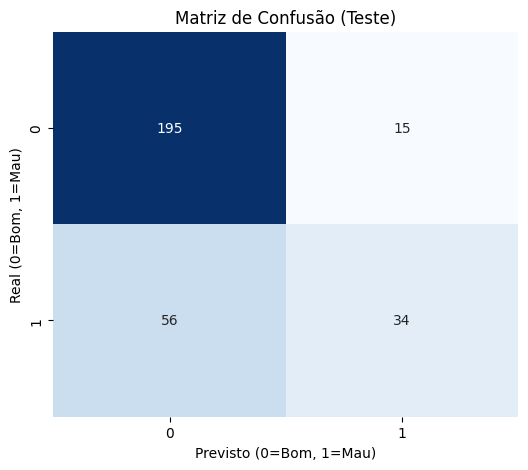

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       210
           1       0.69      0.38      0.49        90

    accuracy                           0.76       300
   macro avg       0.74      0.65      0.67       300
weighted avg       0.75      0.76      0.74       300

ROC-AUC Score: 0.7603


In [11]:
## VENDO OS RESULTADOS DO MODELO

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fazer previsões na base de Teste (que o modelo nunca viu)
y_pred = rf_model_bal.predict(X_test)
y_proba = rf_model_bal.predict_proba(X_test)[:, 1] # Probabilidade de ser "Mau"

# 2. Matriz de Confusão Visual
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão (Teste)')
plt.xlabel('Previsto (0=Bom, 1=Mau)')
plt.ylabel('Real (0=Bom, 1=Mau)')
plt.show()

# 3. Relatório Completo
print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

# 4. AUC-ROC (Nota final do modelo de 0 a 1)
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {auc:.4f}")

In [ ]:
import pandas as pd

feature_imp = pd.Series(rf_model_bal.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp.head(10), y=feature_imp.head(10).index, palette='viridis')
plt.title('Top 10 Variáveis Mais Importantes')
plt.xlabel('Importância')
plt.show()

In [13]:
## NOVA VERSÃO DO MODELO JÁ COM AJUSTE DOS PESOS E AUMENTO DE REGUA PARA CLASSIFCAR MAUS PAGADORES.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

print("=== TREINANDO MODELO BALANCEADO ===")

# 1. Instanciar o modelo com a MÁGICA do class_weight
rf_model_bal = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    random_state=42, 
    class_weight='balanced' # <--- ISSO MUDA TUDO
)

# 2. Treinar
rf_model_bal.fit(X_train, y_train)

# 3. Prever
y_pred_bal = rf_model_bal.predict(X_test)
y_proba_bal = rf_model_bal.predict_proba(X_test)[:, 1]

# 4. Resultados
print("\n--- Relatório de Classificação (Balanceado) ---")
print(classification_report(y_test, y_pred_bal))

auc_bal = roc_auc_score(y_test, y_proba_bal)
print(f"ROC-AUC Score: {auc_bal:.4f}")

=== TREINANDO MODELO BALANCEADO ===

--- Relatório de Classificação (Balanceado) ---
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       210
           1       0.56      0.47      0.51        90

    accuracy                           0.73       300
   macro avg       0.67      0.65      0.66       300
weighted avg       0.72      0.73      0.72       300

ROC-AUC Score: 0.7491


In [ ]:
## VENDO OS RESULTADOS DO MODELO

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Fazer previsões na base de Teste (que o modelo nunca viu)
y_pred = rf_model_bal.predict(X_test)
y_proba = rf_model_bal.predict_proba(X_test)[:, 1] # Probabilidade de ser "Mau"

# 2. Matriz de Confusão Visual
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão (Teste)')
plt.xlabel('Previsto (0=Bom, 1=Mau)')
plt.ylabel('Real (0=Bom, 1=Mau)')
plt.show()

# 3. Relatório Completo
print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

# 4. AUC-ROC (Nota final do modelo de 0 a 1)
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {auc:.4f}")

feature_imp = pd.Series(rf_model_bal.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp.head(10), y=feature_imp.head(10).index, palette='viridis')
plt.title('Top 10 Variáveis Mais Importantes')
plt.xlabel('Importância')
plt.show()

In [15]:
## Testa todos os parâmetros que criamos e retorna o que apresentou melhor resultado


from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

print("=== INICIANDO O TUNING DO MODELO ===")

# 1. Definimos o universo de possibilidades que o robô vai testar
param_grid = {
    'n_estimators': [100, 200, 300, 500],       # Número de árvores
    'max_depth': [5, 8, 10, 15, None],          # Profundidade máxima
    'min_samples_split': [2, 5, 10, 15],        # Mínimo para quebrar um nó
    'min_samples_leaf': [1, 2, 4, 8],           # Mínimo de clientes na folha final
    'class_weight': ['balanced', 'balanced_subsample'] # Mantemos o peso!
}

# 2. Configuramos o "Buscador"
rf_tuner = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=30,             # Vai sortear e testar 30 combinações diferentes
    cv=5,                  # Faz Cross-Validation (divide o treino em 5 partes)
    scoring='roc_auc',     # Nosso objetivo é maximizar a separação (AUC)
    random_state=42,
    n_jobs=-1              # Usa todos os núcleos do seu processador para ir mais rápido
)

# 3. Rodamos a busca (Pode levar alguns segundos)
rf_tuner.fit(X_train, y_train)

print("\n🏆 MELHORES PARÂMETROS ENCONTRADOS:")
print(rf_tuner.best_params_)

# 4. Pegamos o melhor modelo encontrado
melhor_rf = rf_tuner.best_estimator_

# 5. Avaliamos o melhor modelo com aquele nosso corte de 35%
y_proba_otimizado = melhor_rf.predict_proba(X_test)[:, 1]
y_pred_otimizado = (y_proba_otimizado >= 0.47).astype(int)

print("\n=== RESULTADOS DO MODELO OTIMIZADO (Corte 47%) ===")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_otimizado))

=== INICIANDO O TUNING DO MODELO ===

🏆 MELHORES PARÂMETROS ENCONTRADOS:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 10, 'class_weight': 'balanced'}

=== RESULTADOS DO MODELO OTIMIZADO (Corte 47%) ===
              precision    recall  f1-score   support

           0       0.83      0.72      0.77       210
           1       0.50      0.67      0.57        90

    accuracy                           0.70       300
   macro avg       0.67      0.69      0.67       300
weighted avg       0.74      0.70      0.71       300



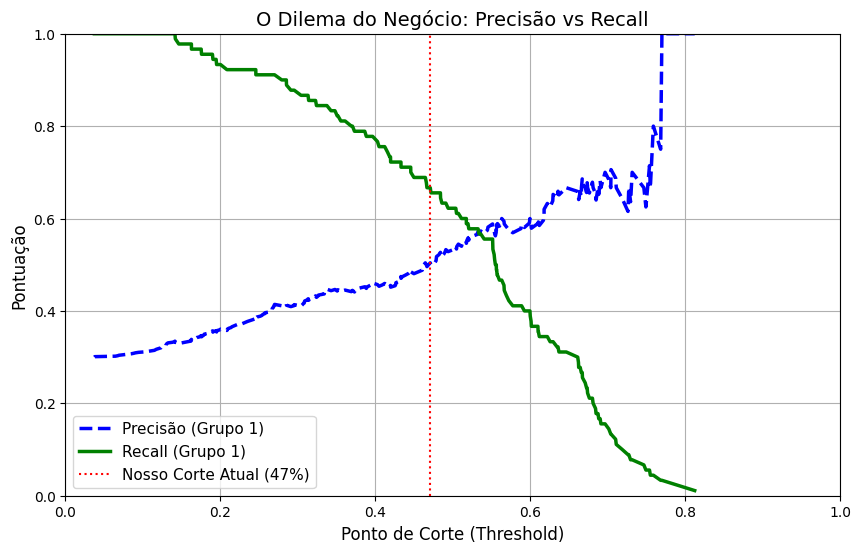

In [16]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Calcula precisão e recall para todos os pontos de corte possíveis
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_otimizado)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precisão (Grupo 1)", linewidth=2.5)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall (Grupo 1)", linewidth=2.5)

# Linha marcando o nosso corte atual de 35%
plt.axvline(x=0.47, color='red', linestyle=':', label='Nosso Corte Atual (47%)')

plt.xlabel("Ponto de Corte (Threshold)", fontsize=12)
plt.ylabel("Pontuação", fontsize=12)
plt.legend(loc="best", fontsize=11)
plt.grid(True)
plt.title("O Dilema do Negócio: Precisão vs Recall", fontsize=14)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("=== CALCULANDO VALORES SHAP ===")

# 1. Cria o explicador
explainer = shap.TreeExplainer(melhor_rf)

# 2. Calcula os valores
shap_values = explainer.shap_values(X_test)

# 3. Tratamento dinâmico para evitar o erro de índice (Lida com várias versões do SHAP)
if isinstance(shap_values, list):
    # Se retornou uma lista, a posição [1] é a chance de calote (Classe 1)
    valores_para_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    # Se retornou um array 3D, pegamos a "fatia" da classe 1
    valores_para_plot = shap_values[:, :, 1]
else:
    # Se já for 2D, usamos direto
    valores_para_plot = shap_values

# 4. Plotando de forma limpa
# Usamos max_display para não esmagar as variáveis e plot_size para garantir as margens
shap.summary_plot(
    valores_para_plot, 
    X_test, 
    max_display=10,      # Limita para as 10 variáveis mais importantes (fica mais elegante)
    plot_size=(10, 6),   # Resolve o problema de ficar "cortado"
    show=True            # Já exibe o gráfico corretamente
)